In [129]:
from myutils import *

In [130]:
from math import *
import numpy as np

from scipy.optimize import minimize, curve_fit


class _ChooseMeasurement:
    def __init__(self, measure):
        if measure.lower() in ('spade', 'di'):
            self.measure = measure.lower()
        else:
            raise ValueError('measure must be one of spade or di')


class DataReader(_ChooseMeasurement):
    def _spade_reader(self, data):
        return data[:, SPADE.point1[0], SPADE.point1[1]], data[:, SPADE.point2[0], SPADE.point2[1]]


    def _di_roi(self, mirrors):
        if mirrors is None:
            raise ValueError('type(mirrors) must be int, ' + 
                             'mirrors stands for how many DMD pixels')
        
        s = mirrors * DMD.pixel_size / qCMOS.pixel_size
        _sigma = Expt.sigma / qCMOS.pixel_size
        
        return np.ceil([DI.center - s - 3*_sigma, DI.center + 3*_sigma]).astype(int)


    def _cropping(self, data, mirrors=None):
        temp = data[:, :-4, :]
        noise = (temp[:, :5,   :5].mean((1, 2)) + temp[:, -5:,   :5].mean((1, 2))  + 
                 temp[:, :5, -5: ].mean((1, 2)) + temp[:, -5:, -5: ].mean((1, 2))) / 4
        
        if self.measure == 'spade':
            cropped = np.array(self._spade_reader(temp)).T
        if self.measure == 'di':
            cropped = temp[:, self._di_roi(mirrors)[0]:self._di_roi(mirrors)[1], DI.ax]
        
        return cropped, noise


    def _reshaping(self, data, noise, length, mirrors=None):
        detectors = 2 if self.measure == 'spade' else - np.subtract(*self._di_roi(mirrors))
        reshaped_data = data[:length, :].reshape(Expt.repeat_times, -1, detectors)[:, :Expt.samples_length, :]
        reshaped_noise = noise[:length].reshape(Expt.repeat_times, -1)[:, :Expt.samples_length]
        return reshaped_data, reshaped_noise


    def _processing(self, avi, length, mirrors=None):
        avi = read(avi).astype(float)
        cropped, noise = self._cropping(avi, mirrors)
        return self._reshaping(cropped, noise, length, mirrors)
    

    def load(self, files, lengths, mirrors=None):
        if len(files) != len(lengths):
            raise ValueError('len(files) and len(lengths) must be the same')
        else:
            l = len(files)

        processed, noise = zip(*[
            self._processing(files[i], lengths[i], mirrors) for i in range(l)])
        
        raw, noise = np.array(processed), np.array(noise)
        photons = raw.sum(-1)

        return raw, photons, noise




class TDEst(_ChooseMeasurement):
    def _normalize(self, data):
        data = np.array(data)
        temp = data - data.mean()
        scale = (temp[temp>0].mean() - temp[temp<0].mean()) / 2
        return temp / scale
    

    @cache
    def estimator(self, dataset, noise=None, di_method='mle'):
        origin_shape = dataset.shape

        detectors = origin_shape[-1]
        works = np.prod(origin_shape[:-1])

        flatten_data = dataset.reshape(-1, detectors)

        if self.measure == 'di':
            if di_method.lower() == 'simple':
                temp = flatten_data / flatten_data.sum(axis=-1).reshape(-1, 1)
                x_axis = np.arange(detectors)
                time_domain = (temp @ x_axis)

            elif di_method.lower() == 'mle':
                def _p(x, s, w):
                    _sigma = Expt.sigma / qCMOS.pixel_size
                    return (1-w)/np.sqrt(tau*_sigma**2)*np.exp(-(x-s)**2/(2*_sigma**2)) + w/detectors
                
                def _negative_ll(data, w):
                    x_axis = np.arange(detectors)
                    return lambda s: - data.T @ np.log(_p(x_axis, s, w)) / data.sum()
                
                def _run_mle(data, w):
                    # Use BFGS algorithm to minimize negative log-likelihood function.
                    result = minimize(_negative_ll(data, w), x0=detectors/2, method='BFGS')
                    
                    if result.success:
                        return result.x[0]
                    else:
                        raise RuntimeError('not converged')
                
                if noise is None:
                    time_domain = [_run_mle(flatten_data[i], 0) for i in range(works)]
                else:
                    w_set = np.ravel(noise) / flatten_data.mean(-1)
                    time_domain = [_run_mle(flatten_data[i], w_set[i]) for i in range(works)]  

        if self.measure == 'spade':
            # SPADE's time domain estmator is extremely simple.
            time_domain = flatten_data[:, 0] - flatten_data[:, 1]

        return self._normalize(time_domain).reshape(*origin_shape[:-1])




class FreqEst:
    def __init__(self, est_phi=False, phi=None):
        if type(est_phi) == bool:
            self.est_phi = est_phi

        if not self.est_phi:
            if type(phi) in (int, float):
                self.phi = phi
            else:
                raise ValueError('phi must be given')


    def _normalize_phase(self, phase):
        # Normalize phase to be within [0, 2*pi)
        phase = phase % tau
        # Adjust phase to be within [-pi, pi)
        if phase > pi:
            phase -= tau
        return phase
    

    def waveform(self, n, f, phi, a):
        return a * np.cos(tau * f * n + phi)


    # Use FFT as pre-estimator.
    def fft_estimator(self, signal):
        l = len(signal)

        fft = np.fft.fft(signal)[:l // 2]
        freq = np.fft.fftfreq(l, Expt.expo_time)[:l // 2]
        
        amplitude = np.abs(fft)
        phase = np.angle(fft)

        peak_index = np.argmax(amplitude[1:]) + 1
        freq_est = freq[peak_index]
        phase_est = phase[peak_index]
        
        return freq_est / Expt.sampling_rate, self._normalize_phase(phase_est)
    

    # Use LSE as frequency estimator. 
    # Note that LSE and MLE are the same in WGN.
    def lse_estimator(self, dataset):
        N = dataset.shape[-1]
        n = np.arange(N, dtype=np.float64)
        
        if self.est_phi:
            s = lambda n, f, phi: self.waveform(n, f, phi, 1)
        else:
            s = lambda n, f: self.waveform(n, f, self.phi, 1)

        freq_est, phi_est = [], []
        for group in dataset:
            for data in group:
                f_init, phi_init = self.fft_estimator(data)
                init = [f_init, phi_init] if self.est_phi else [f_init]
                popt, pcov = curve_fit(s, n, data, init)

                if np.linalg.cond(pcov) <= 5e5:
                    if self.est_phi:
                        freq_est.append(popt[0])
                        phi_est.append(popt[1])
                    else:
                        freq_est.append(popt.item())
                        phi_est.append(phi_init)
                else:
                    raise RuntimeError('np.linalg.cond(pcov) > 50000, the algorithm may not converge')

        return np.array(freq_est).reshape(*dataset.shape[:-1]), np.array(phi_est).reshape(*dataset.shape[:-1])


    def fim(self, f, phi, a):
        n = np.arange(Expt.samples_length)
        fi11 = (n**2 * np.sin(tau * f * n + phi)**2).sum()
        fi12 = (n**1 * np.sin(tau * f * n + phi)**2).sum()
        fi22 = (n**0 * np.sin(tau * f * n + phi)**2).sum()

        if self.est_phi:
            matrix = np.array([[fi11, fi12],
                               [fi12, fi22]])
        else:
            matrix = fi11

        return tau**2 * a**2 * matrix


    def fim_approxed(self, a):
        n = np.arange(Expt.samples_length)
        fi11 = (n**2).sum()
        fi12 = (n**1).sum()
        fi22 = (n**0).sum()

        if self.est_phi:
            matrix = np.array([[fi11, fi12],
                               [fi12, fi22]])
        else:
            matrix = fi11

        return tau**2 * a**2 * matrix / 2


In [131]:
# class DI(_Share):
#     ax = 81
#     center = 110


In [132]:
def LSE(sample):
    # Normalize time
    temp = sample - sample.mean()
    scale = (temp[temp>0].mean() - temp[temp<0].mean()) / 2
    sample = temp / scale

    def normalize_phase(phase):
        # Normalize phase to be within [0, 2*pi)
        phase = phase % tau
        # Adjust phase to be within [-pi, pi)
        if phase > pi:
            phase -= tau
        return phase


    def waveform(n, f, phi):
        return np.cos(tau * f * n + phi)


    # Use FFT as pre-estimator.
    def pre_estimator():
        l = len(sample)

        fft = np.fft.fft(sample)[:l // 2]
        freq = np.fft.fftfreq(l, 1)[:l // 2]
        
        amplitude = np.abs(fft)
        phi = np.angle(fft)

        peak_index = np.argmax(amplitude[1:]) + 1
        pre_freq_est = freq[peak_index]
        pre_phi_est = phi[peak_index]

        return pre_freq_est, normalize_phase(pre_phi_est)
    

    # Use LSE as frequency estimator. 
    # Note that LSE and MLE are the same in WGN.
    n = np.arange(len(sample), dtype=np.float64)
    popt, pcov = curve_fit(f=waveform, xdata=n, ydata=sample, p0=pre_estimator())

    if np.linalg.cond(pcov) <= 5e5:
        freq_est, phi_est = popt
    else:
        raise RuntimeError('np.linalg.cond(pcov) > 50000, the algorithm may not converge')

    return freq_est, phi_est



In [133]:
class _Share:
    @classmethod
    def load(cls, file):
        cls.file = file


    @classmethod
    def read(cls):
        cls.raw = np.load(cls.file).astype(float)


    @classmethod
    def freq_est(cls):
        cls.freq, cls.phi = zip(*[LSE(sample) for sample in cls.td])
        cls.freq, cls.phi = np.array(cls.freq), np.array(cls.phi)

        

In [134]:
class SPADE(_Share):
    POINT_1 = (89, 119)
    POINT_2 = (89, 407)


    @classmethod
    def crop(cls):
        cls.cropped = np.transpose(
            np.array([cls.raw[:, :, y, x] for x, y in (cls.POINT_1, cls.POINT_2)]), axes=(1, 2, 0))
        

    @classmethod
    def photons(cls):
        cls.pn = cls.cropped.sum(-1) - 400


    @classmethod
    def td_est(cls):
        cls.td = cls.cropped[:, :, 0] - cls.cropped[:, :, 1]




In [135]:
varlist = []
pnlist = []
philist = []
for freq in Expt.freq_list:
    SPADE.load(f'spade_{freq}.npy')

    SPADE.read()
    SPADE.crop()
    SPADE.photons()
    SPADE.td_est()
    SPADE.freq_est()

    pnlist.append(SPADE.pn.mean())
    varlist.append(SPADE.freq.var())
    philist.append(SPADE.phi.mean())

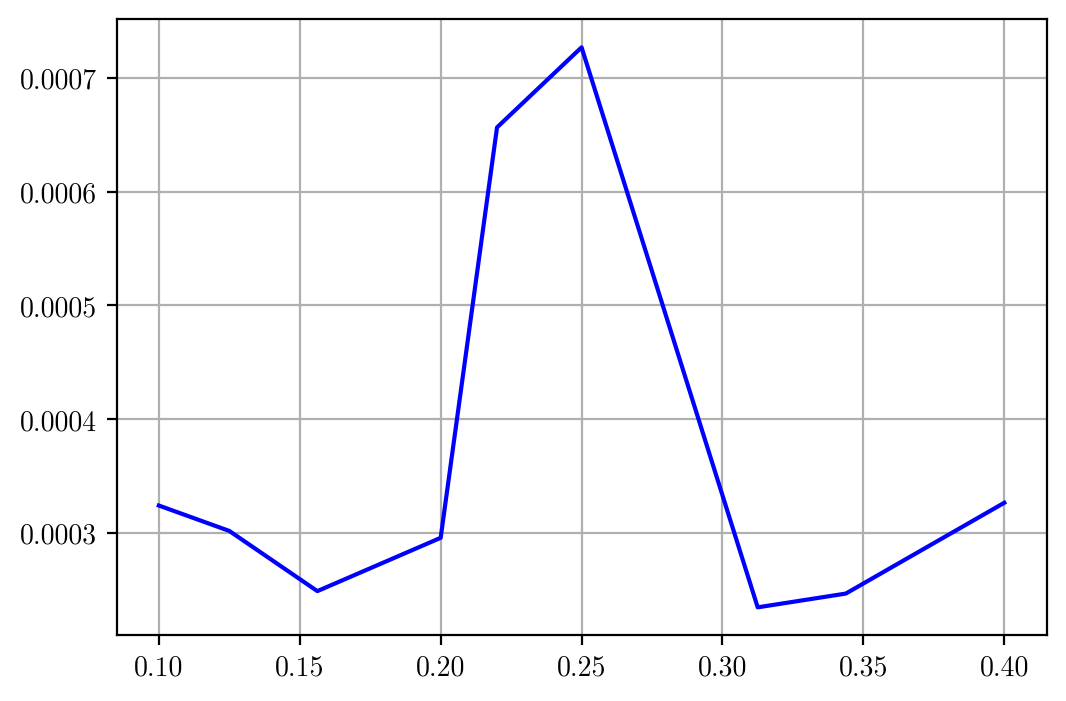

In [136]:
plot(Expt.freq_list, np.array(varlist) * np.array(pnlist))


In [137]:
def fim(f, phi=0.5*pi):
    a = 5 * DMD.pixel_size / 2 / 103
    n = np.arange(50)
    fi11 = (n**2 * np.sin(tau * f * n + phi)**2).sum()
    fi12 = (n**1 * np.sin(tau * f * n + phi)**2).sum()
    fi22 = (n**0 * np.sin(tau * f * n + phi)**2).sum()

    matrix = np.array([[fi11, fi12],
                       [fi12, fi22]])

    return tau**2 * a**2 * matrix

In [143]:
qcrb = [np.linalg.inv(fim(Expt.freq_list[i]))[0,0] for i in range(9)]

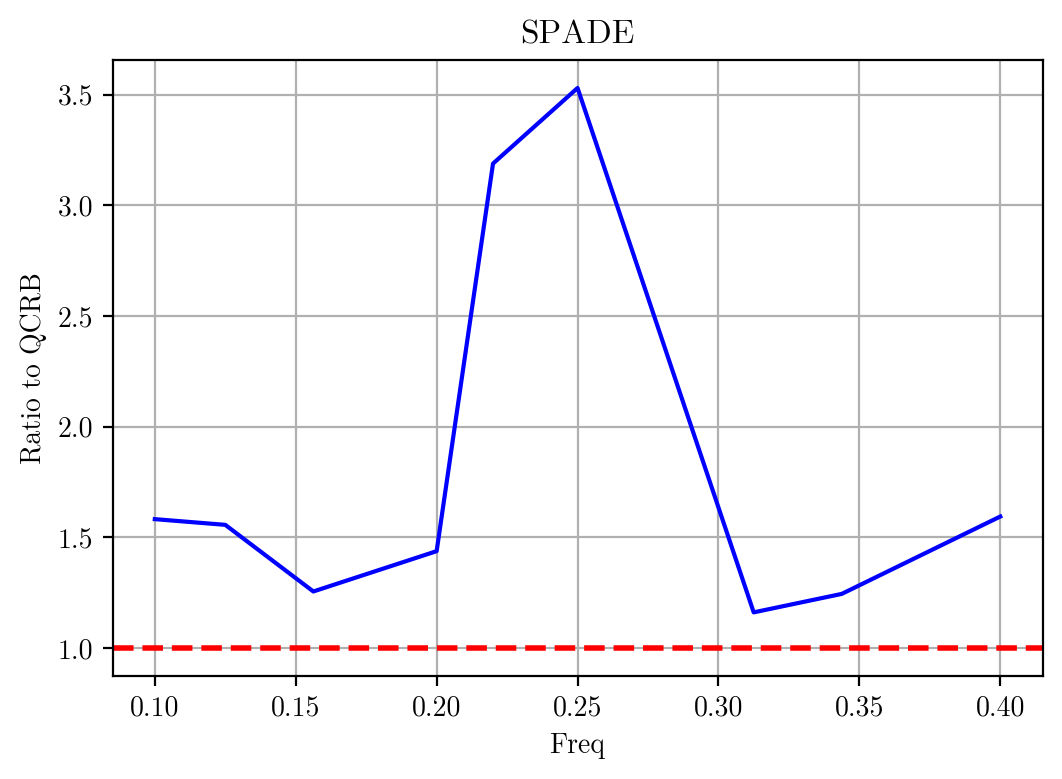

In [154]:
plot(Expt.freq_list, np.array(varlist) * np.array(pnlist) * 0.107 / np.array(qcrb))
axline(h=1, c='r', w=2)
plot([], xlabel='Freq', ylabel='Ratio to QCRB', title='SPADE')

In [153]:
code(axline)

In [ ]:
SPADE.load('spade_0.25.npy')

In [ ]:
SPADE.read()
SPADE.crop()
SPADE.photons()
SPADE.td_est()
SPADE.freq_est()

ValueError: not enough values to unpack (expected 2, got 1)

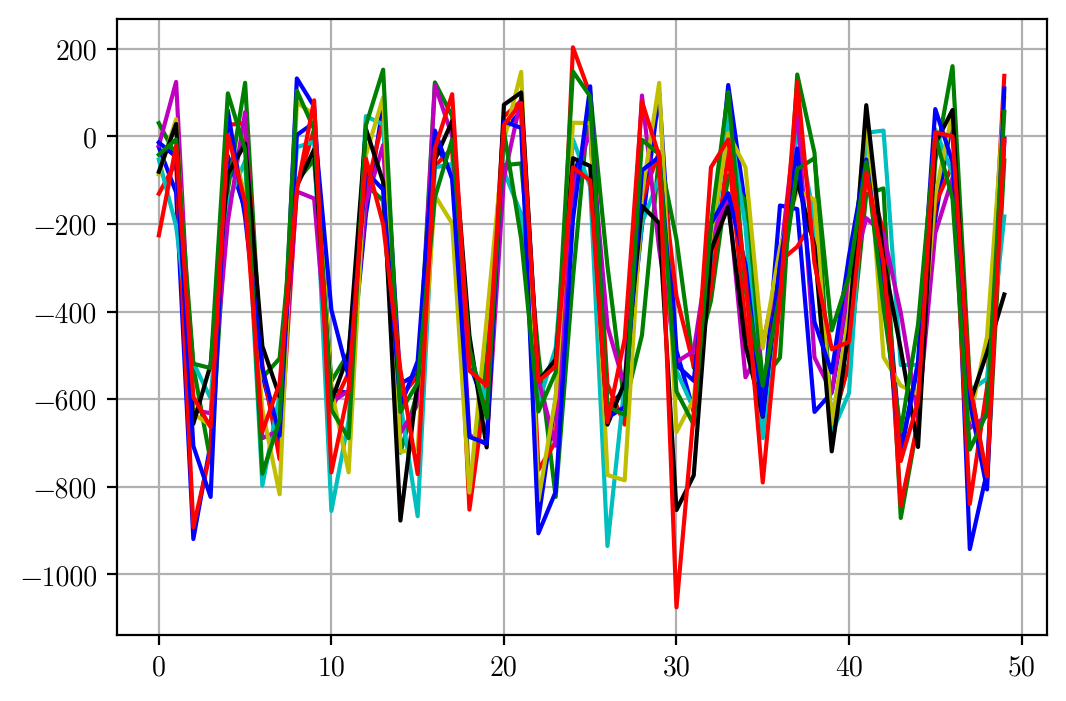

In [ ]:
for i in range(10):
    plot(SPADE.td[i])

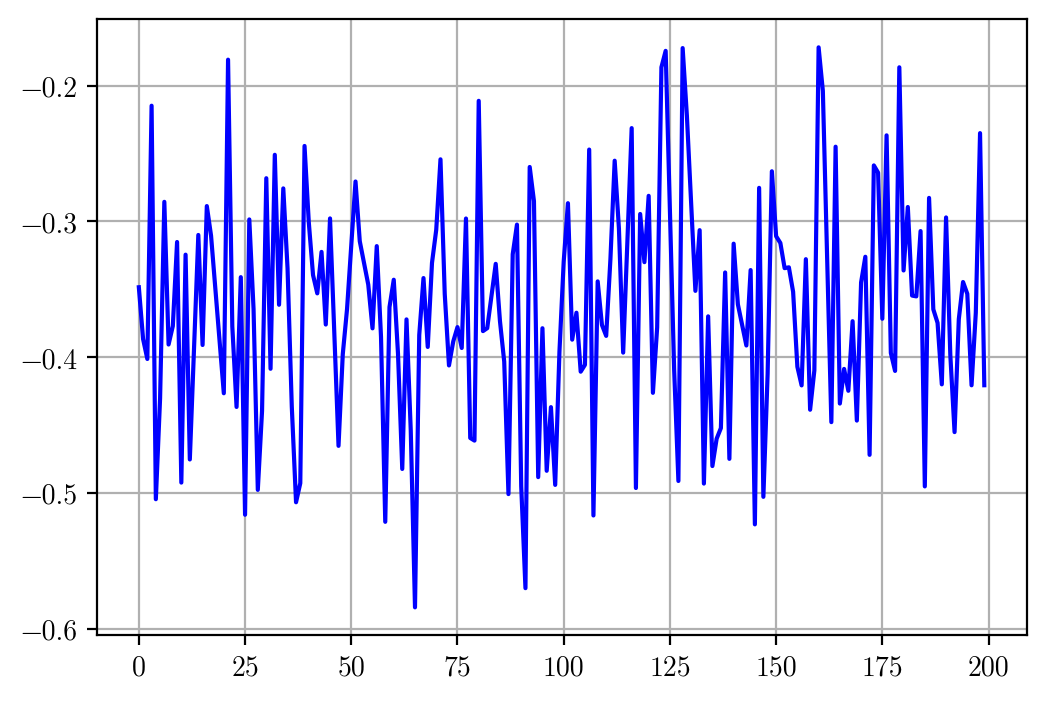

In [ ]:
plot(SPADE.phi)

In [ ]:
read('timestamp_0.25.npy')[0]

array(['2024-10-18 16:14:38.001180', '2024-10-18 16:14:38.046180',
       '2024-10-18 16:14:38.091180', '2024-10-18 16:14:38.136180',
       '2024-10-18 16:14:38.181180', '2024-10-18 16:14:38.226180',
       '2024-10-18 16:14:38.271180', '2024-10-18 16:14:38.316180',
       '2024-10-18 16:14:38.361180', '2024-10-18 16:14:38.406180',
       '2024-10-18 16:14:38.451180', '2024-10-18 16:14:38.496180',
       '2024-10-18 16:14:38.541180', '2024-10-18 16:14:38.586180',
       '2024-10-18 16:14:38.631180', '2024-10-18 16:14:38.676180',
       '2024-10-18 16:14:38.721180', '2024-10-18 16:14:38.766180',
       '2024-10-18 16:14:38.811180', '2024-10-18 16:14:38.856180',
       '2024-10-18 16:14:38.901180', '2024-10-18 16:14:38.946180',
       '2024-10-18 16:14:38.991180', '2024-10-18 16:14:39.036180',
       '2024-10-18 16:14:39.081180', '2024-10-18 16:14:39.126180',
       '2024-10-18 16:14:39.171180', '2024-10-18 16:14:39.216180',
       '2024-10-18 16:14:39.261180', '2024-10-18 16:14:39.3061

In [ ]:
45*49 / 1000

2.205

In [ ]:
38 + 2.205

40.205

In [155]:
1/0.22

4.545454545454546